# HW1 实验报告

## 从零开始构建三层神经网络分类器，实现 Fashion-MNIST 图像分类

- 姓名：谢唯
- 学号：23307130044


In [1]:
import csv
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "reports":
    PROJECT_ROOT = PROJECT_ROOT.parent
SEARCH_DIR = PROJECT_ROOT / "artifacts" / "search_real"
FINAL_DIR = PROJECT_ROOT / "artifacts" / "final_model"
EVAL_DIR = FINAL_DIR / "evaluation"

SEARCH_RESULTS_PATH = SEARCH_DIR / "search_results.csv"
SEARCH_SUMMARY_PATH = SEARCH_DIR / "search_summary.json"
SUMMARY_PATH = FINAL_DIR / "summary.json"
CONFIG_PATH = FINAL_DIR / "config.json"
HISTORY_PATH = FINAL_DIR / "history.json"
TEST_METRICS_PATH = EVAL_DIR / "test_metrics.json"
CONFUSION_CSV_PATH = EVAL_DIR / "confusion_matrix.csv"
TRAINING_CURVES_PATH = FINAL_DIR / "training_curves.png"
CONFUSION_PNG_PATH = EVAL_DIR / "confusion_matrix.png"
FIRST_LAYER_PNG_PATH = EVAL_DIR / "first_layer_weights.png"
ERROR_PNG_PATH = EVAL_DIR / "error_examples.png"

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))


def to_relative_path(value):
    path = Path(value)
    if not path.is_absolute():
        return str(path)
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def sanitize_for_display(value):
    if isinstance(value, dict):
        return {key: sanitize_for_display(item) for key, item in value.items()}
    if isinstance(value, list):
        return [sanitize_for_display(item) for item in value]
    if isinstance(value, str) and ("/" in value or "\\" in value):
        return to_relative_path(value)
    return value


def show_image(path: Path, title: str, figsize=(8, 6)):
    image = mpimg.imread(path)
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


search_df = pd.read_csv(SEARCH_RESULTS_PATH).sort_values("best_val_accuracy", ascending=False).reset_index(drop=True)
summary = load_json(SUMMARY_PATH)
config = load_json(CONFIG_PATH)
history = load_json(HISTORY_PATH)
test_metrics = load_json(TEST_METRICS_PATH)
display_summary = sanitize_for_display(summary)
display_config = sanitize_for_display(config)
display_search_df = search_df.copy()
if "output_dir" in display_search_df.columns:
    display_search_df["output_dir"] = display_search_df["output_dir"].map(to_relative_path)

with CONFUSION_CSV_PATH.open("r", encoding="utf-8") as handle:
    rows = list(csv.reader(handle))
confusion_matrix = np.array([[int(value) for value in row[1:]] for row in rows[1:]], dtype=np.int64)

print("Report environment ready.")
print("Project root:", ".")
print("Final artifact dir:", to_relative_path(FINAL_DIR))
print("Evaluation dir:", to_relative_path(EVAL_DIR))


Report environment ready.
Project root: .
Final artifact dir: artifacts/final_model
Evaluation dir: artifacts/final_model/evaluation


## 1. 任务说明

本次作业要求使用 `NumPy` 从零实现三层神经网络分类器，在 `Fashion-MNIST` 数据集上完成 10 类服装图像分类。要求：

- 自主实现自动微分与反向传播，不使用 `PyTorch`、`TensorFlow`、`JAX`
- 代码包含数据加载与预处理、模型定义、训练循环、测试评估、超参数搜索模块
- 模型支持可配置隐藏层维度，并支持至少两种激活函数
- 训练中实现 `SGD`、学习率衰减、交叉熵损失与 `L2` 正则
- 按验证集准确率保存最优模型
- 在独立测试集上输出准确率和混淆矩阵
- 在报告中展示训练曲线、第一层权重可视化与错例分析


## 2. 实现概述

项目模块如下：

- `src/autograd.py`：实现 `Tensor`、计算图构建、自动微分和 `backward()`
- `src/nn.py`：实现 `Linear`、`MLP`、参数保存和加载
- `src/optim.py`：实现 `SGD` 和学习率衰减策略
- `src/data.py`：下载与解析 `Fashion-MNIST` 的 IDX 格式数据，并完成训练/验证划分
- `src/training.py`：训练循环、验证集选模、训练曲线导出
- `src/search.py`：超参数搜索
- `src/visualization.py`：混淆矩阵、第一层权重与错例图可视化

最终选用的正式模型结构为 `784 -> 256 -> 128 -> 10`，激活函数为 `tanh`。


In [2]:
print("最终训练配置：")
print(json.dumps(display_config, indent=2, ensure_ascii=False))
print()
print("最终结果摘要：")
print(json.dumps(display_summary, indent=2, ensure_ascii=False))


最终训练配置：
{
  "data_dir": "data/fashion-mnist",
  "output_dir": "artifacts/final_model",
  "hidden_dims": [
    256,
    128
  ],
  "activation": "tanh",
  "epochs": 20,
  "batch_size": 256,
  "learning_rate": 0.1,
  "lr_scheduler": "step",
  "lr_gamma": 0.5,
  "lr_step_size": 5,
  "weight_decay": 0.0001,
  "val_ratio": 0.1,
  "seed": 42,
  "download": false,
  "input_dim": 784,
  "num_classes": 10,
  "verbose": true
}

最终结果摘要：
{
  "best_epoch": 20,
  "best_val_accuracy": 0.8696666666666667,
  "test_accuracy": 0.8616,
  "output_dir": "artifacts/final_model",
  "model_path": "artifacts/final_model/best_model.npz"
}


## 3. 超参数搜索

进行了随机搜索。搜索范围包括：

- 学习率：`0.1`、`0.05`、`0.02`
- 隐藏层结构：`(128,)`、`(256,)`、`(256, 128)`
- 权重衰减：`1e-4`、`5e-4`
- 激活函数：`relu`、`tanh`

评价标准使用验证集准确率，最终保留验证集表现最好的组合。


In [3]:
print("超参数搜索结果（按验证集准确率降序排序）：")
print(display_search_df.to_string(index=False))
print()
print("搜索阶段最优组合：")
best_row = display_search_df.iloc[0]
print(best_row.to_string())


超参数搜索结果（按验证集准确率降序排序）：
 trial  learning_rate hidden_dims  weight_decay activation  best_epoch  best_val_accuracy  test_accuracy                      output_dir
     1           0.10     256,128        0.0001       tanh           8           0.853500         0.8463 artifacts/search_real/trial_001
     3           0.10         256        0.0001       tanh           8           0.848667         0.8405 artifacts/search_real/trial_003
     2           0.05         128        0.0001       relu           6           0.835833         0.8288 artifacts/search_real/trial_002
     6           0.05         256        0.0005       tanh           8           0.834167         0.8313 artifacts/search_real/trial_006
     5           0.02     256,128        0.0001       relu           8           0.828167         0.8253 artifacts/search_real/trial_005
     4           0.02         128        0.0005       tanh           8           0.816000         0.8107 artifacts/search_real/trial_004

搜索阶段最优组合：
trial   

从搜索结果可以看到，`tanh` 激活函数在当前实现和学习率设置下比 `relu` 更稳定。隐藏层稍深的 `256 -> 128` 结构也优于单隐藏层模型，因此正式训练采用该配置。


## 4. 训练过程与收敛情况

正式训练共运行 `20` 个 epoch，并使用 `step decay` 学习率衰减策略。


训练过程关键结果：
Best epoch: 20
Best validation accuracy: 0.8697
Test accuracy: 0.8616

后 5 个 epoch 的记录：
 epoch  train_loss  train_accuracy  val_loss  val_accuracy  learning_rate
    16    0.345336        0.876667  0.363088      0.867167         0.0125
    17    0.344209        0.876833  0.363592      0.866500         0.0125
    18    0.343405        0.877333  0.361786      0.867833         0.0125
    19    0.342364        0.877815  0.361250      0.867833         0.0125
    20    0.341226        0.878037  0.360663      0.869667         0.0125


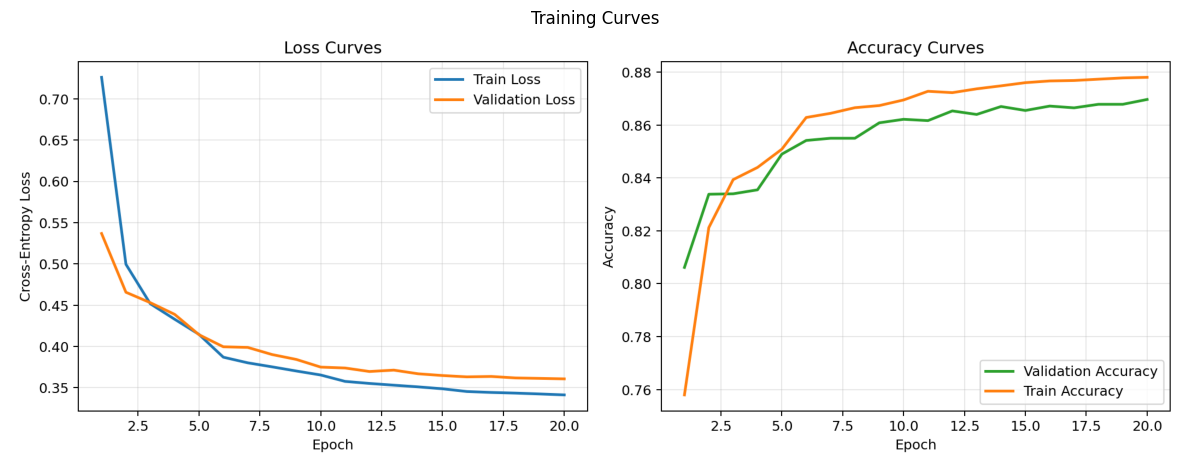

In [4]:
print("训练过程关键结果：")
print(f"Best epoch: {summary['best_epoch']}")
print(f"Best validation accuracy: {summary['best_val_accuracy']:.4f}")
print(f"Test accuracy: {summary['test_accuracy']:.4f}")
print()
print("后 5 个 epoch 的记录：")
tail_df = pd.DataFrame(history).tail(5)
print(tail_df.to_string(index=False))
show_image(TRAINING_CURVES_PATH, "Training Curves", figsize=(12, 4.8))


从曲线可以看到，训练损失和验证损失整体都在稳定下降，验证集准确率在后期仍有缓慢上升，说明当前模型尚未出现明显过拟合。最终验证集最佳准确率达到 `0.8697`。


## 5. 测试集结果与混淆矩阵



测试集指标：
{
  "test_loss": 0.3898329113960266,
  "test_accuracy": 0.8616
}

各类别召回率：
      class  correct  total  recall
        Bag      966   1000  0.9660
    Trouser      960   1000  0.9600
 Ankle boot      942   1000  0.9420
    Sneaker      937   1000  0.9370
     Sandal      930   1000  0.9300
      Dress      882   1000  0.8820
T-shirt/top      844   1000  0.8440
   Pullover      794   1000  0.7940
       Coat      777   1000  0.7770
      Shirt      584   1000  0.5840


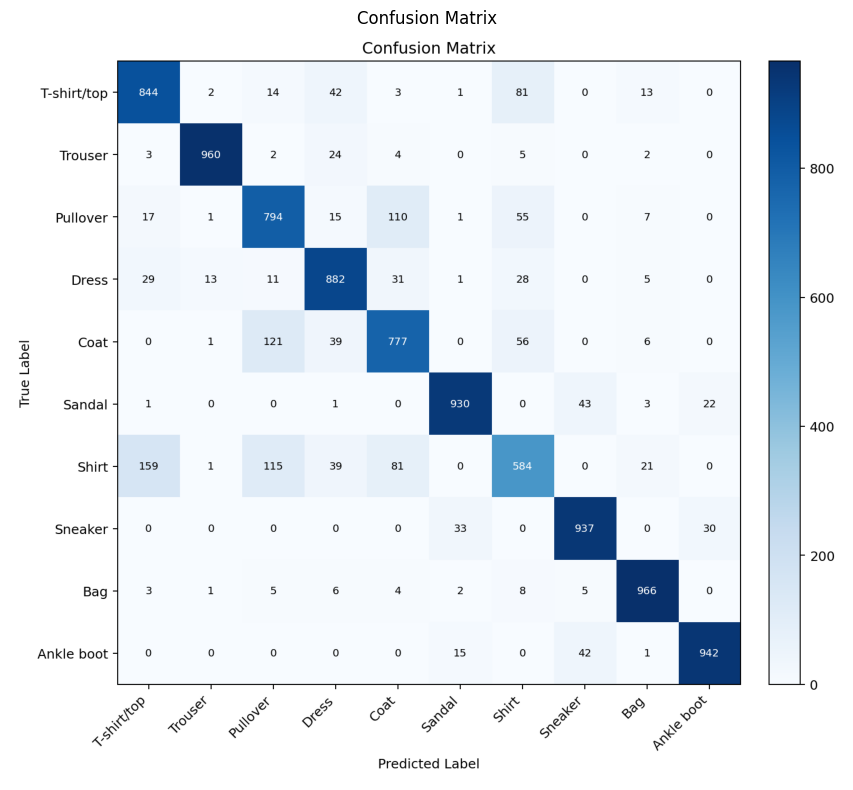

In [5]:
print("测试集指标：")
print(json.dumps(test_metrics, indent=2, ensure_ascii=False))
print()

class_totals = confusion_matrix.sum(axis=1)
class_correct = np.diag(confusion_matrix)
class_recall = class_correct / class_totals
per_class_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "correct": class_correct,
    "total": class_totals,
    "recall": class_recall,
}).sort_values("recall", ascending=False)
print("各类别召回率：")
print(per_class_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
show_image(CONFUSION_PNG_PATH, "Confusion Matrix", figsize=(9, 8))


测试集准确率为 `0.8616`。从混淆矩阵可以看出，轮廓接近、纹理差异较小的上装类别更容易相互混淆，而 `Trouser`、`Bag`、`Ankle boot` 等形状更鲜明的类别更容易被正确分类。


## 6. 第一层权重可视化

为观察网络在输入空间中学到的模式，我将第一层权重矩阵恢复成 `28 x 28` 图像。每个隐藏单元对应一个模板，它反映了模型更关注哪些边缘、轮廓和局部区域。

这里展示前64个：


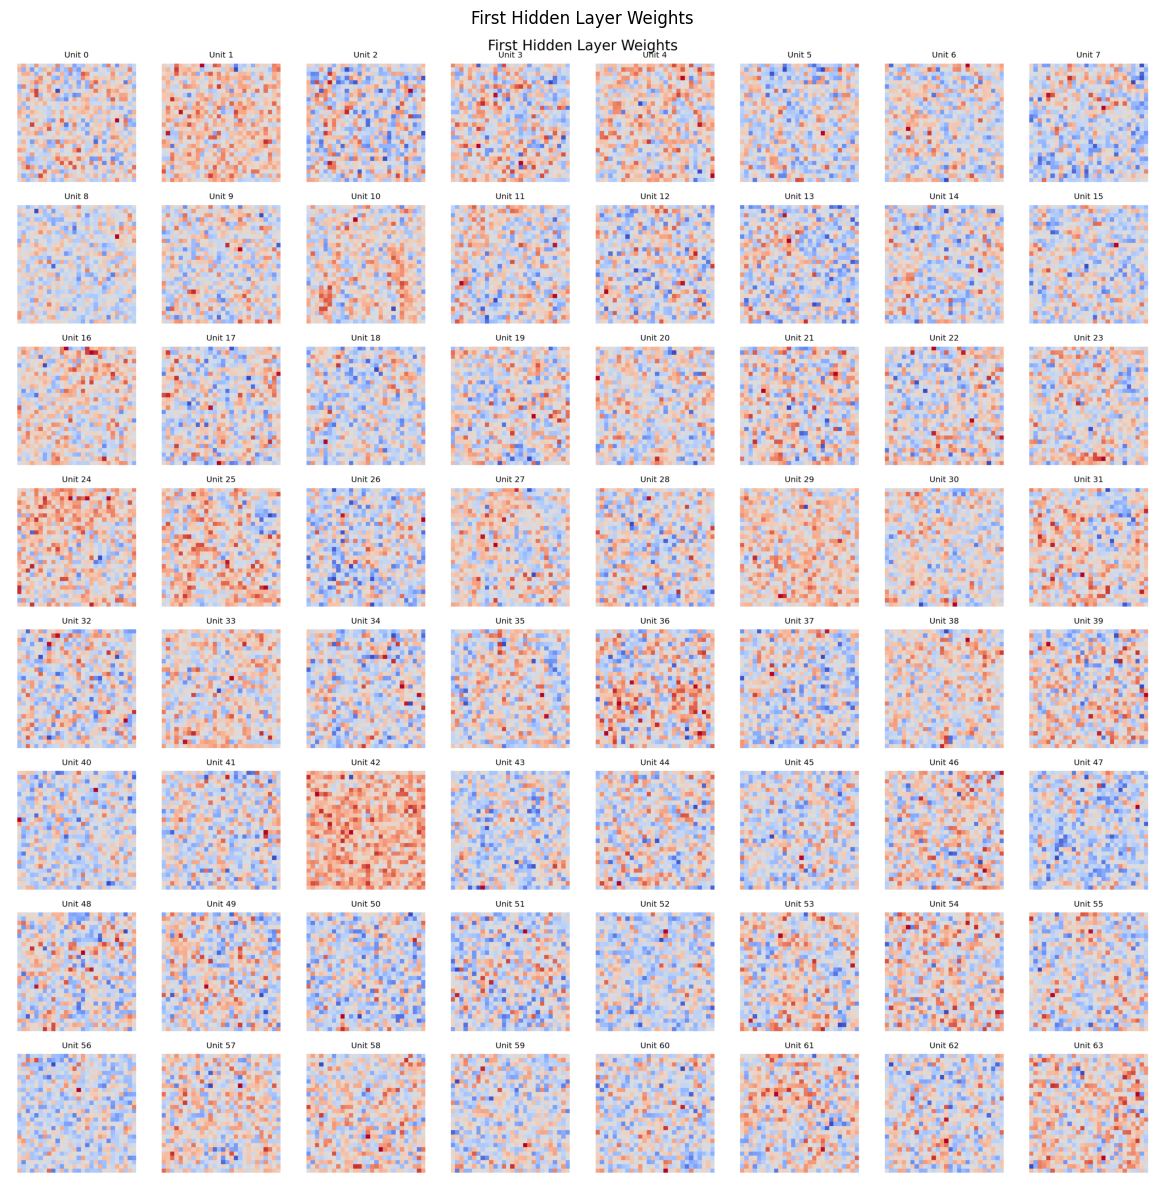

In [6]:
show_image(FIRST_LAYER_PNG_PATH, "First Hidden Layer Weights", figsize=(12, 12))


从这些权重模板中可以看到：

- Unit10似乎在识别衣服的两个袖子

- Unit27，57似乎在识别包的手提袋

- Unit25有点像凉鞋的形状

## 7. 错例分析

除总体准确率外，错例分析更能反映模型的真实短板。我统计了测试集中最主要的错分对，并结合错分样本图像进行观察。


最常见的 10 个错分对：
       Shirt -> T-shirt/top : 159
        Coat -> Pullover    : 121
       Shirt -> Pullover    : 115
    Pullover -> Coat        : 110
 T-shirt/top -> Shirt       : 81
       Shirt -> Coat        : 81
        Coat -> Shirt       : 56
    Pullover -> Shirt       : 55
      Sandal -> Sneaker     : 43
 T-shirt/top -> Dress       : 42


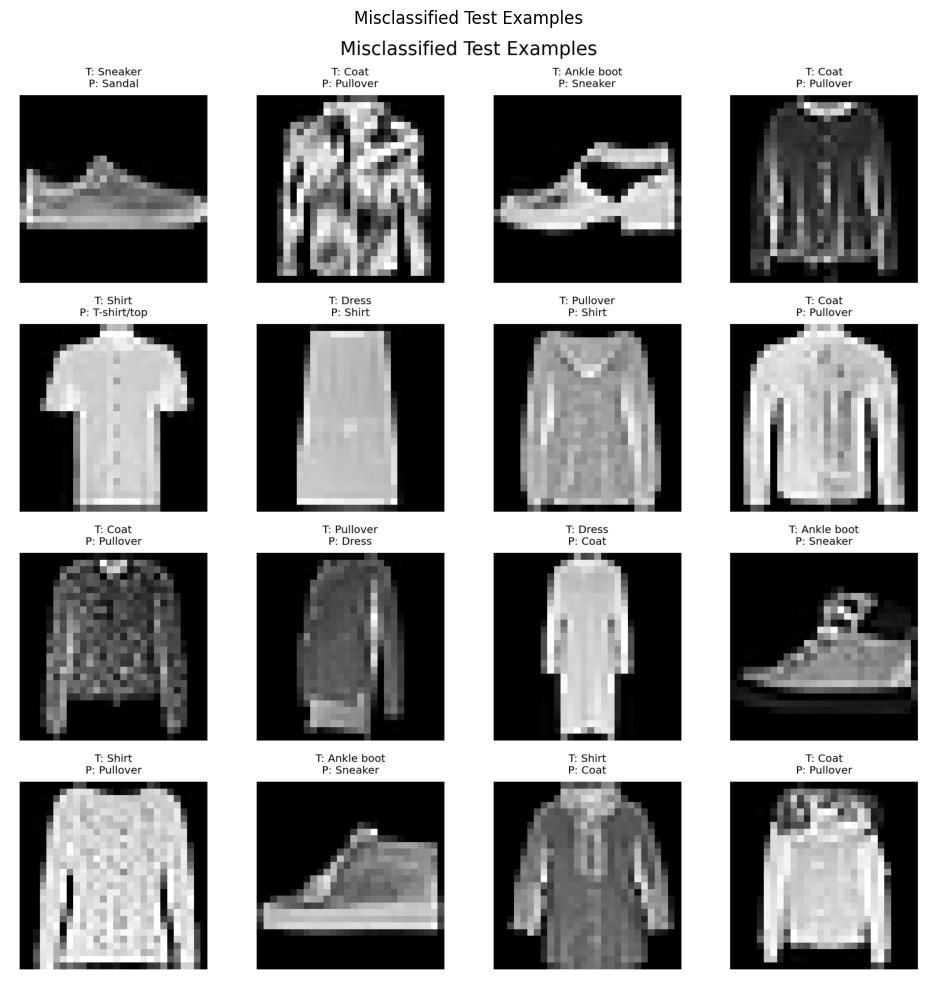

In [7]:
confusion_pairs = []
for true_idx, true_name in enumerate(CLASS_NAMES):
    for pred_idx, pred_name in enumerate(CLASS_NAMES):
        if true_idx == pred_idx:
            continue
        count = int(confusion_matrix[true_idx, pred_idx])
        if count > 0:
            confusion_pairs.append((count, true_name, pred_name))
confusion_pairs.sort(reverse=True)

print("最常见的 10 个错分对：")
for count, true_name, pred_name in confusion_pairs[:10]:
    print(f"{true_name:>12s} -> {pred_name:<12s}: {count}")

show_image(ERROR_PNG_PATH, "Misclassified Test Examples", figsize=(10, 10))


结合混淆矩阵和错分样本，可以得到以下结论：

- `Shirt`、`T-shirt/top`、`Pullover`、`Coat` 是最难区分的几类，因为它们都属于上装，整体轮廓接近
- 鞋类之间的混淆主要出现在 `Sandal` 与 `Sneaker`，侧视图下的轮廓相似


## 8. 复现实验

训练和评估命令如下：

```bash
python scripts/train.py           --data-dir data/fashion-mnist           --output-dir artifacts/final_model           --hidden-dims 256,128           --activation tanh           --epochs 20           --batch-size 256           --learning-rate 0.1           --lr-scheduler step           --lr-gamma 0.5           --lr-step-size 5           --weight-decay 0.0001           --val-ratio 0.1           --seed 42

python scripts/evaluate.py           --artifact-dir artifacts/final_model           --data-dir data/fashion-mnist           --output-dir artifacts/final_model/evaluation
```


## 9. 提交信息

提交材料信息如下：

- GitHub Repo: `https://github.com/twothsnd/hw1_fashion_mnist`
- Model Weights Download: `https://pan.baidu.com/s/1lCKtDl2byjsPVCNrDmNHRA`
- 提取码：`zytd`


